In [13]:
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import numpy as np
import math

In [15]:
# Replace the keys in this dicitonnary to match the names of the PREVis subscales columns in your data.set
# Each of these 4 columns should contain the average of the subscale's ratings for each participant (row).
colors = {
    "Understand" : ['#4ba1bc','#829599'],
    "Layout" : ['#839e49', '#969b86'],
    "DataRead" : ['#a87c9f', '#a396a0'],
    "DataFeat" : ['#e08095', '#c6b6ba']
}
subscales = list(colors.keys())
colors = ['#4ba1bc', '#839e49', '#a87c9f', '#e08095']

# Visualizations
visualizations = {
    "Matrix": {
        "label": "Matrix",
    },
    "SimilarityView": {
        "label": "Similarity View",
    },
}
visualizations_keys = list(visualizations.keys())

Creating Matrix visualization...
   PID VisExpertise Visualization  Understand  Layout  DataRead  DataFeat
0    1       Expert        Matrix        6.67    6.33      5.67       6.0
2    2    NonExpert        Matrix        6.67    6.67      5.67       6.0
4    3       Expert        Matrix        7.00    5.67      5.00       6.0
6    4    NonExpert        Matrix        6.00    6.67      6.33       6.0
Creating Similarity View visualization...
   PID VisExpertise   Visualization  Understand  Layout  DataRead  DataFeat
1    1       Expert  SimilarityView        5.67    6.67      7.00       6.0
3    2    NonExpert  SimilarityView        6.00    5.33      6.33       5.0
5    3       Expert  SimilarityView        7.00    6.00      5.00       6.0
7    4    NonExpert  SimilarityView        3.67    6.33      4.67       6.0


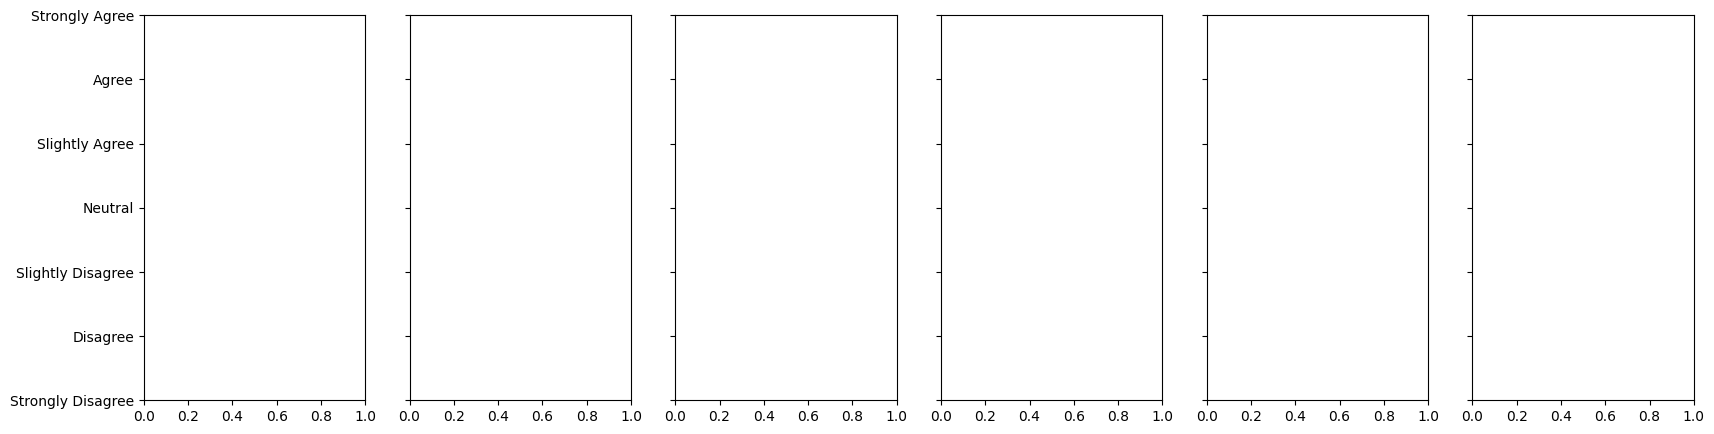

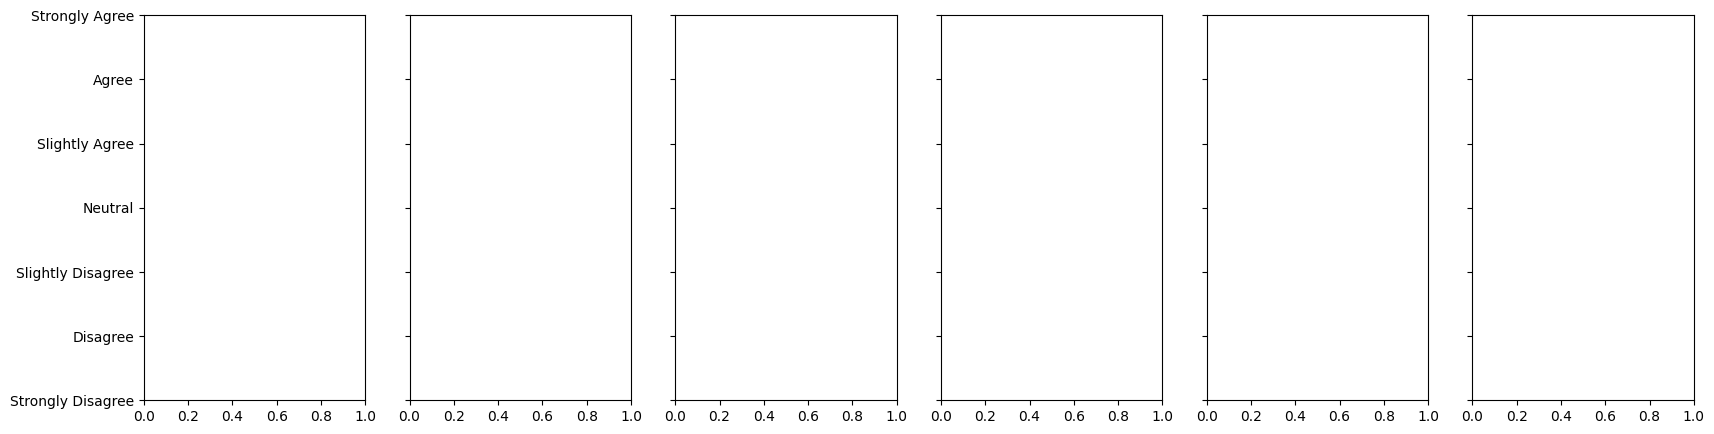

In [ ]:
df = pd.read_csv('previs_scores_averages.csv')

for visualization_key in visualizations_keys:
    visualization = visualizations[visualization_key]
    print(f"Creating {visualization['label']} visualization...")
    
    # Get only rows for the current visualization
    df_vis = df[df['Visualization'] == visualization_key]
    
    print(df_vis.head())
    """
       PID VisExpertise Visualization  Understand  Layout  DataRead  DataFeat
  0    1       Expert        Matrix        6.67    6.33      5.67       6.0
  2    2    NonExpert        Matrix        6.67    6.67      5.67       6.0
  4    3       Expert        Matrix        7.00    5.67      5.00       6.0
  6    4    NonExpert        Matrix        6.00    6.67      6.33       6.0
    """
    
    """
    Figure
    - 6 subplots in 1 row
    - each subplot is a grouped bar plot
    - y-axis is shared across all subplots
    - x-axis has the labels for the subplots    
    """
    fig, axs = plt.subplots(1, 6, figsize=(20, 5), sharey=True)
    
    # set the y-axis
    y_ticks = [1,2,3,4,5,6,7]
    y_labels = ['Strongly Disagree', 'Disagree', 'Slightly Disagree', 'Neutral', 'Slightly Agree', 'Agree', 'Strongly Agree']
    
    # set the y-axis limits
    y_min = 1
    y_max = 7
    axs[0].set_ylim(y_min, y_max)
    axs[0].set_yticks(y_ticks)
    axs[0].set_yticklabels(y_labels)

    # each subplot is a grouped bar chart
        
    
    
    
    
    
    
    
    

Creating Matrix visualization...


TypeError: 'list' object is not callable

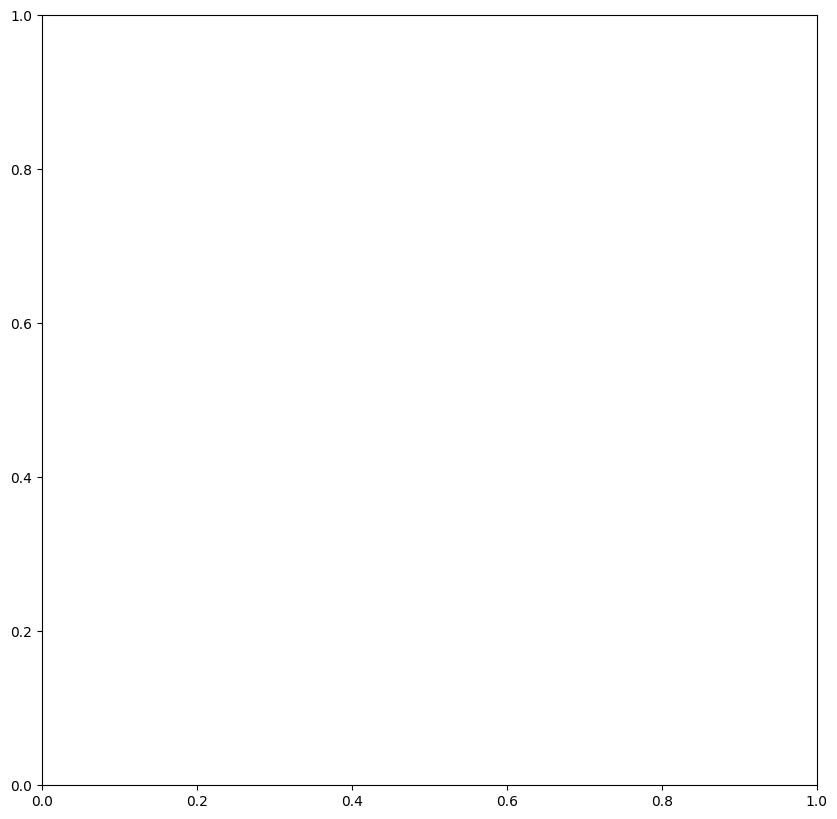

In [ ]:
df = pd.read_csv('previs_scores_averages.csv')

# variables
num_subscales = 4
num_participants = 6
w = 1.0

first_tick = int(math.ceil((num_subscales*w/2))) 
gap = num_subscales*w + 1
x = np.array([first_tick + i*gap for i in range(num_participants)])

for visualization_key in visualizations_keys:
    visualization = visualizations[visualization_key]
    print(f"Creating {visualization['label']} visualization...")
    
    # Get only rows for the current visualization
    df_vis = df[df['Visualization'] == visualization_key]


    fig,ax = plt.subplots(1,1, figsize=(10,10))
    b = []
    for i in range(num_subscales):
        b.append(ax.bar(x - (i - num_subscales/2 + 0.5)*w, 
                df_vis.iloc[:, i+3], # I guess this works because the first 3 columns are not subscales
                width=w, 
                color=colors[i], 
                align='center', 
                edgecolor = 'black', 
                linewidth = 1.0, 
                alpha=0.5))
        ax.legend([b_ for b_ in b], 
            subscales, 
            ncol = 3, # ??? 
            loc = 'best', 
            framealpha = 0.1)
            
    ax.set_ylabel('Goals')
    ax.set_xlabel('Players')
    ax.set_title('Goals scored by players')
    ax.set_xticks(x)
    ax.set_xticklabels(df_vis['PID'])
    for i in range(num_subscales):
        ax.bar_label(b[i], 
                    padding = 3, 
                    label_type='center', 
                    rotation = 'vertical')
    plt.show()